In [31]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, SVR

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


## 1. Load Datasets

In [32]:

# Change these paths if your files are stored elsewhere.
CAR_PATH = "dataset/car.data"
BRAIN_PATH = r"dataset\DT-BrainCancer.csv"
WAGE_PATH = r"dataset\DT-Wage.csv"
CREDIT_PATH = r"dataset\DT-Credit.csv"

car_columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]

car_df = pd.read_csv(CAR_PATH, header=None, names=car_columns)
brain_df = pd.read_csv(BRAIN_PATH)
wage_df = pd.read_csv(WAGE_PATH)
credit_df = pd.read_csv(CREDIT_PATH)

for name, df in {
    "Car Evaluation": car_df,
    "Brain Cancer": brain_df,
    "Wage": wage_df,
    "Credit": credit_df
}.items():
    print(f"{name}: {df.shape}")


Car Evaluation: (1728, 7)
Brain Cancer: (88, 7)
Wage: (3000, 11)
Credit: (400, 11)


In [33]:

display(car_df.head())
display(brain_df.head())
display(wage_df.head())
display(credit_df.head())

print("Brain columns:", brain_df.columns.tolist())
print("Wage columns:", wage_df.columns.tolist())
print("Credit columns:", credit_df.columns.tolist())


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


,Unnamed: 0,sex,diagnosis,loc,ki,gtv,status
0,1,Female,Meningioma,Infratentorial,90,6.11,0
1,2,Male,HG glioma,Supratentorial,90,19.35,1
2,3,Female,Meningioma,Infratentorial,70,7.95,0
3,4,Female,LG glioma,Supratentorial,80,7.61,1
4,5,Male,HG glioma,Supratentorial,90,5.06,1


,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


,Income,Limit,Rating,Cards,Age,Education,Own,Student,Married,Region,Balance
0,14.891,3606,283,2,34,11,No,No,Yes,South,333
1,106.025,6645,483,3,82,15,Yes,Yes,Yes,West,903
2,104.593,7075,514,4,71,11,No,No,No,West,580
3,148.924,9504,681,3,36,11,Yes,No,No,West,964
4,55.882,4897,357,2,68,16,No,No,Yes,South,331


Brain columns: ['Unnamed: 0', 'sex', 'diagnosis', 'loc', 'ki', 'gtv', 'status']
Wage columns: ['year', 'age', 'maritl', 'race', 'education', 'region', 'jobclass', 'health', 'health_ins', 'logwage', 'wage']
Credit columns: ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Own', 'Student', 'Married', 'Region', 'Balance']


## 2. 70% / 15% / 15% Split

In [34]:

def split_dataset(df):
    train, temporary = train_test_split(
        df, test_size=0.30, shuffle=False
    )
    validation, test = train_test_split(
        temporary, test_size=0.50, shuffle=False
    )
    return train, validation, test

car_train, car_val, car_test = split_dataset(car_df)
brain_train, brain_val, brain_test = split_dataset(brain_df)
wage_train, wage_val, wage_test = split_dataset(wage_df)
credit_train, credit_val, credit_test = split_dataset(credit_df)

datasets = {
    "Car Evaluation": (car_train, car_val, car_test),
    "Brain Cancer": (brain_train, brain_val, brain_test),
    "Wage": (wage_train, wage_val, wage_test),
    "Credit": (credit_train, credit_val, credit_test)
}

for name, (tr, va, te) in datasets.items():
    n = len(tr) + len(va) + len(te)
    print(f"{name}: Train={len(tr)} ({len(tr)/n:.2%}), "
          f"Validation={len(va)} ({len(va)/n:.2%}), "
          f"Test={len(te)} ({len(te)/n:.2%})")


Car Evaluation: Train=1209 (69.97%), Validation=259 (14.99%), Test=260 (15.05%)
Brain Cancer: Train=61 (69.32%), Validation=13 (14.77%), Test=14 (15.91%)
Wage: Train=2100 (70.00%), Validation=450 (15.00%), Test=450 (15.00%)
Credit: Train=280 (70.00%), Validation=60 (15.00%), Test=60 (15.00%)


## 3. Evaluation Functions

In [35]:

def classification_results(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

def regression_results(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

def show_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = np.unique(np.concatenate([np.asarray(y_true), np.asarray(y_pred)]))
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


# Part A — Car Evaluation

In [36]:

car_X = ["buying", "maint", "doors", "persons", "lug_boot", "safety"]
car_y = "class"

X_car_train, y_car_train = car_train[car_X], car_train[car_y]
X_car_val, y_car_val = car_val[car_X], car_val[car_y]
X_car_test, y_car_test = car_test[car_X], car_test[car_y]

car_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_car_train_e = car_encoder.fit_transform(X_car_train)
X_car_val_e = car_encoder.transform(X_car_val)
X_car_test_e = car_encoder.transform(X_car_test)


### ZeroR

In [37]:

zeroR_car = DummyClassifier(strategy="most_frequent")
zeroR_car.fit(X_car_train_e, y_car_train)
zeroR_car_test_pred = zeroR_car.predict(X_car_test_e)
zeroR_car_test_results = classification_results(y_car_test, zeroR_car_test_pred)
print(zeroR_car_test_results)


{'Accuracy': 0.5538461538461539, 'Precision': 0.13846153846153847, 'Recall': 0.25, 'F1-Score': 0.1782178217821782}


### OneR-style Classifier

In [38]:

# Library-based OneR-style decision stump.
oneR_car = DecisionTreeClassifier(max_depth=1, random_state=42)
oneR_car.fit(X_car_train_e, y_car_train)
oneR_car_test_pred = oneR_car.predict(X_car_test_e)
oneR_car_test_results = classification_results(y_car_test, oneR_car_test_pred)
print(oneR_car_test_results)


{'Accuracy': 0.5538461538461539, 'Precision': 0.13846153846153847, 'Recall': 0.25, 'F1-Score': 0.1782178217821782}


### KNN — Select K on Validation Set

In [39]:

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
rows = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_car_train_e, y_car_train)
    pred = model.predict(X_car_val_e)
    rows.append({"K": k, **classification_results(y_car_val, pred)})

knn_car_validation = pd.DataFrame(rows)
display(knn_car_validation)

best_k_car = int(knn_car_validation.loc[knn_car_validation["Accuracy"].idxmax(), "K"])
knn_car = KNeighborsClassifier(n_neighbors=best_k_car)
knn_car.fit(X_car_train_e, y_car_train)
knn_car_test_pred = knn_car.predict(X_car_test_e)
knn_car_test_results = classification_results(y_car_test, knn_car_test_pred)
print("Selected K:", best_k_car)
print("Test:", knn_car_test_results)


,K,Accuracy,Precision,Recall,F1-Score
0,1,0.621622,0.177313,0.250000,0.207474
1,3,0.664093,0.248050,0.295082,0.266857
2,5,0.621622,0.177313,0.250000,0.207474
3,7,0.621622,0.177313,0.250000,0.207474
4,9,0.621622,0.177313,0.250000,0.207474
5,11,0.621622,0.177313,0.250000,0.207474
6,15,0.621622,0.177313,0.250000,0.207474
7,21,0.621622,0.177313,0.250000,0.207474


Selected K: 3
Test: {'Accuracy': 0.6, 'Precision': 0.2468944099378882, 'Recall': 0.3333333333333333, 'F1-Score': 0.2776442307692308}


### Naive Bayes — Select `var_smoothing` on Validation Set

In [40]:

smoothing_values = [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
rows = []

for s in smoothing_values:
    model = GaussianNB(var_smoothing=s)
    model.fit(X_car_train_e, y_car_train)
    pred = model.predict(X_car_val_e)
    rows.append({"var_smoothing": s, **classification_results(y_car_val, pred)})

nb_car_validation = pd.DataFrame(rows)
display(nb_car_validation)

best_nb_car = nb_car_validation.loc[nb_car_validation["Accuracy"].idxmax()]
best_nb_car_smoothing = float(best_nb_car["var_smoothing"])

nb_car = GaussianNB(var_smoothing=best_nb_car_smoothing)
nb_car.fit(X_car_train_e, y_car_train)
nb_car_test_pred = nb_car.predict(X_car_test_e)
nb_car_test_results = classification_results(y_car_test, nb_car_test_pred)

print("Selected var_smoothing:", best_nb_car_smoothing)
print("Test:", nb_car_test_results)


,var_smoothing,Accuracy,Precision,Recall,F1-Score
0,1.000000e-11,0.849421,0.619898,0.654731,0.624009
1,1.000000e-10,0.849421,0.619898,0.654731,0.624009
2,1.000000e-09,0.849421,0.619898,0.654731,0.624009
3,1.000000e-08,0.849421,0.619898,0.654731,0.624009
4,1.000000e-07,0.849421,0.619898,0.654731,0.624009
5,1.000000e-06,0.849421,0.619898,0.654731,0.624009
6,1.000000e-05,0.849421,0.619898,0.654731,0.624009
7,1.000000e-04,0.849421,0.619898,0.654731,0.624009
8,1.000000e-03,0.849421,0.619898,0.654731,0.624009


Selected var_smoothing: 1e-11
Test: {'Accuracy': 0.676923076923077, 'Precision': 0.325, 'Recall': 0.4930555555555556, 'F1-Score': 0.36186348862405204}


### SVM — Select Parameters on Validation Set

In [41]:

C_values = [0.1, 1, 10, 100]
gamma_values = ["scale", "auto", 0.001, 0.01, 0.1, 1]
kernel_values = ["linear", "rbf"]

rows = []
for kernel in kernel_values:
    for C in C_values:
        for gamma in gamma_values:
            model = SVC(C=C, kernel=kernel, gamma=gamma)
            model.fit(X_car_train_e, y_car_train)
            pred = model.predict(X_car_val_e)
            rows.append({
                "Kernel": kernel, "C": C, "Gamma": gamma,
                **classification_results(y_car_val, pred)
            })

svm_car_validation = pd.DataFrame(rows)
display(svm_car_validation.sort_values("Accuracy", ascending=False).head(10))

best_svm_car = svm_car_validation.loc[svm_car_validation["Accuracy"].idxmax()]

svm_car = SVC(
    C=best_svm_car["C"],
    kernel=best_svm_car["Kernel"],
    gamma=best_svm_car["Gamma"]
)
svm_car.fit(X_car_train_e, y_car_train)
svm_car_test_pred = svm_car.predict(X_car_test_e)
svm_car_test_results = classification_results(y_car_test, svm_car_test_pred)

display(pd.DataFrame([best_svm_car]))
print("Test:", svm_car_test_results)


,Kernel,C,Gamma,Accuracy,Precision,Recall,F1-Score
43,rbf,100.0,auto,0.791506,0.784648,0.584607,0.647345
46,rbf,100.0,0.1,0.779923,0.790584,0.582919,0.646614
12,linear,10.0,scale,0.764479,0.738339,0.534703,0.591565
13,linear,10.0,auto,0.764479,0.738339,0.534703,0.591565
17,linear,10.0,1,0.764479,0.738339,0.534703,0.591565
16,linear,10.0,0.1,0.764479,0.738339,0.534703,0.591565
14,linear,10.0,0.001,0.764479,0.738339,0.534703,0.591565
15,linear,10.0,0.01,0.764479,0.738339,0.534703,0.591565
19,linear,100.0,auto,0.764479,0.738339,0.534703,0.591565
18,linear,100.0,scale,0.764479,0.738339,0.534703,0.591565


,Kernel,C,Gamma,Accuracy,Precision,Recall,F1-Score
43,rbf,100.0,auto,0.791506,0.784648,0.584607,0.647345


Test: {'Accuracy': 0.6038461538461538, 'Precision': 0.48339871112356403, 'Recall': 0.3423202614379085, 'F1-Score': 0.3255641107465381}


# Part B — Brain Cancer

In [42]:

# Inspect these columns first. If your CSV uses different names, edit the variables below.
print(brain_df.columns.tolist())

brain_y = "status"
brain_X = ["sex", "diagnosis", "loc", "ki", "gtv"]

# Remove accidental index column if present.
for df in [brain_train, brain_val, brain_test]:
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

X_brain_train, y_brain_train = brain_train[brain_X], brain_train[brain_y]
X_brain_val, y_brain_val = brain_val[brain_X], brain_val[brain_y]
X_brain_test, y_brain_test = brain_test[brain_X], brain_test[brain_y]

brain_cat = ["sex", "diagnosis", "loc"]
brain_num = ["ki", "gtv"]

brain_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), brain_cat),
    ("num", StandardScaler(), brain_num)
])

X_brain_train_e = brain_preprocessor.fit_transform(X_brain_train)
X_brain_val_e = brain_preprocessor.transform(X_brain_val)
X_brain_test_e = brain_preprocessor.transform(X_brain_test)


['Unnamed: 0', 'sex', 'diagnosis', 'loc', 'ki', 'gtv', 'status']


### Brain Cancer — ZeroR, OneR, KNN, Naive Bayes, SVM

In [43]:

zeroR_brain = DummyClassifier(strategy="most_frequent")
zeroR_brain.fit(X_brain_train_e, y_brain_train)
zeroR_brain_test_pred = zeroR_brain.predict(X_brain_test_e)
zeroR_brain_test_results = classification_results(y_brain_test, zeroR_brain_test_pred)

oneR_brain = DecisionTreeClassifier(max_depth=1, random_state=42)
oneR_brain.fit(X_brain_train_e, y_brain_train)
oneR_brain_test_pred = oneR_brain.predict(X_brain_test_e)
oneR_brain_test_results = classification_results(y_brain_test, oneR_brain_test_pred)

# KNN
rows = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_brain_train_e, y_brain_train)
    pred = model.predict(X_brain_val_e)
    rows.append({"K": k, **classification_results(y_brain_val, pred)})
knn_brain_validation = pd.DataFrame(rows)
best_k_brain = int(knn_brain_validation.loc[knn_brain_validation["Accuracy"].idxmax(), "K"])

knn_brain = KNeighborsClassifier(n_neighbors=best_k_brain)
knn_brain.fit(X_brain_train_e, y_brain_train)
knn_brain_test_pred = knn_brain.predict(X_brain_test_e)
knn_brain_test_results = classification_results(y_brain_test, knn_brain_test_pred)

# Naive Bayes
rows = []
for s in smoothing_values:
    model = GaussianNB(var_smoothing=s)
    model.fit(X_brain_train_e, y_brain_train)
    pred = model.predict(X_brain_val_e)
    rows.append({"var_smoothing": s, **classification_results(y_brain_val, pred)})
nb_brain_validation = pd.DataFrame(rows)
best_nb_brain = nb_brain_validation.loc[nb_brain_validation["Accuracy"].idxmax()]
best_nb_brain_smoothing = float(best_nb_brain["var_smoothing"])

nb_brain = GaussianNB(var_smoothing=best_nb_brain_smoothing)
nb_brain.fit(X_brain_train_e, y_brain_train)
nb_brain_test_pred = nb_brain.predict(X_brain_test_e)
nb_brain_test_results = classification_results(y_brain_test, nb_brain_test_pred)

# SVM
rows = []
for kernel in kernel_values:
    for C in C_values:
        for gamma in gamma_values:
            model = SVC(C=C, kernel=kernel, gamma=gamma)
            model.fit(X_brain_train_e, y_brain_train)
            pred = model.predict(X_brain_val_e)
            rows.append({
                "Kernel": kernel, "C": C, "Gamma": gamma,
                **classification_results(y_brain_val, pred)
            })

svm_brain_validation = pd.DataFrame(rows)
best_svm_brain = svm_brain_validation.loc[svm_brain_validation["Accuracy"].idxmax()]

svm_brain = SVC(
    C=best_svm_brain["C"],
    kernel=best_svm_brain["Kernel"],
    gamma=best_svm_brain["Gamma"]
)
svm_brain.fit(X_brain_train_e, y_brain_train)
svm_brain_test_pred = svm_brain.predict(X_brain_test_e)
svm_brain_test_results = classification_results(y_brain_test, svm_brain_test_pred)

print("ZeroR:", zeroR_brain_test_results)
print("OneR:", oneR_brain_test_results)
print("KNN:", knn_brain_test_results)
print("Naive Bayes:", nb_brain_test_results)
print("SVM:", svm_brain_test_results)


ZeroR: {'Accuracy': 0.7857142857142857, 'Precision': 0.39285714285714285, 'Recall': 0.5, 'F1-Score': 0.44}
OneR: {'Accuracy': 0.7142857142857143, 'Precision': 0.6444444444444444, 'Recall': 0.696969696969697, 'F1-Score': 0.65}
KNN: {'Accuracy': 0.8571428571428571, 'Precision': 0.8, 'Recall': 0.9090909090909092, 'F1-Score': 0.825}
Naive Bayes: {'Accuracy': 0.5714285714285714, 'Precision': 0.6666666666666666, 'Recall': 0.7272727272727273, 'F1-Score': 0.5625}
SVM: {'Accuracy': 0.7857142857142857, 'Precision': 0.75, 'Recall': 0.8636363636363636, 'F1-Score': 0.7543859649122806}


# Part C — Wage Regression

In [44]:

print(wage_df.columns.tolist())

# Standard Wage dataset configuration.
wage_y = "wage"
wage_cat = ["maritl", "race", "education", "region", "jobclass", "health", "health_ins"]
wage_num = ["year", "age", "logwage"]

X_wage_train, y_wage_train = wage_train.drop(columns=[wage_y]), wage_train[wage_y]
X_wage_val, y_wage_val = wage_val.drop(columns=[wage_y]), wage_val[wage_y]
X_wage_test, y_wage_test = wage_test.drop(columns=[wage_y]), wage_test[wage_y]

wage_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), wage_cat),
    ("num", StandardScaler(), wage_num)
])

X_wage_train_e = wage_preprocessor.fit_transform(X_wage_train)
X_wage_val_e = wage_preprocessor.transform(X_wage_val)
X_wage_test_e = wage_preprocessor.transform(X_wage_test)


['year', 'age', 'maritl', 'race', 'education', 'region', 'jobclass', 'health', 'health_ins', 'logwage', 'wage']


### SVR — Select Parameters on Validation Set

In [45]:

svr_C_values = [0.1, 1, 10, 100]
svr_epsilon_values = [0.01, 0.1, 0.5, 1]
svr_kernel_values = ["linear", "rbf"]
svr_gamma_values = ["scale", "auto"]

rows = []
for kernel in svr_kernel_values:
    for C in svr_C_values:
        for epsilon in svr_epsilon_values:
            for gamma in svr_gamma_values:
                model = SVR(kernel=kernel, C=C, epsilon=epsilon, gamma=gamma)
                model.fit(X_wage_train_e, y_wage_train)
                pred = model.predict(X_wage_val_e)
                rows.append({
                    "Kernel": kernel, "C": C, "Epsilon": epsilon, "Gamma": gamma,
                    **regression_results(y_wage_val, pred)
                })

svr_wage_validation = pd.DataFrame(rows)
display(svr_wage_validation.sort_values("RMSE").head(10))

best_svr_wage = svr_wage_validation.loc[svr_wage_validation["RMSE"].idxmin()]

svr_wage = SVR(
    kernel=best_svr_wage["Kernel"],
    C=best_svr_wage["C"],
    epsilon=best_svr_wage["Epsilon"],
    gamma=best_svr_wage["Gamma"]
)
svr_wage.fit(X_wage_train_e, y_wage_train)
wage_test_pred = svr_wage.predict(X_wage_test_e)
wage_test_results = regression_results(y_wage_test, wage_test_pred)

display(pd.DataFrame([best_svr_wage]))
print("Test:", wage_test_results)


,Kernel,C,Epsilon,Gamma,MAE,MSE,RMSE,R2
61,rbf,100.0,0.50,auto,0.557689,1.701656,1.304475,0.999122
59,rbf,100.0,0.10,auto,0.390460,1.943657,1.394151,0.998997
57,rbf,100.0,0.01,auto,0.366650,2.003013,1.415278,0.998967
63,rbf,100.0,1.00,auto,0.794058,2.114434,1.454109,0.998909
56,rbf,100.0,0.01,scale,0.580828,5.570956,2.360287,0.997126
58,rbf,100.0,0.10,scale,0.627667,5.860019,2.420748,0.996977
60,rbf,100.0,0.50,scale,0.856197,6.983760,2.642681,0.996397
62,rbf,100.0,1.00,scale,1.118597,8.218333,2.866763,0.995761
49,rbf,10.0,0.01,auto,1.884857,43.414481,6.588967,0.977604
51,rbf,10.0,0.10,auto,1.891140,43.530621,6.597774,0.977544


,Kernel,C,Epsilon,Gamma,MAE,MSE,RMSE,R2
61,rbf,100.0,0.5,auto,0.557689,1.701656,1.304475,0.999122


Test: {'MAE': 0.5860698645952329, 'MSE': 2.2550470373097125, 'RMSE': np.float64(1.5016814033974426), 'R2': 0.9987573222451231}


# Part D — Credit Regression

In [46]:

print(credit_df.columns.tolist())

# Standard Credit dataset configuration.
credit_y = "Balance"
credit_cat = ["Own", "Student", "Married", "Region"]
credit_num = ["Income", "Limit", "Rating", "Cards", "Age", "Education"]

X_credit_train, y_credit_train = credit_train.drop(columns=[credit_y]), credit_train[credit_y]
X_credit_val, y_credit_val = credit_val.drop(columns=[credit_y]), credit_val[credit_y]
X_credit_test, y_credit_test = credit_test.drop(columns=[credit_y]), credit_test[credit_y]

credit_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), credit_cat),
    ("num", StandardScaler(), credit_num)
])

X_credit_train_e = credit_preprocessor.fit_transform(X_credit_train)
X_credit_val_e = credit_preprocessor.transform(X_credit_val)
X_credit_test_e = credit_preprocessor.transform(X_credit_test)


['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Own', 'Student', 'Married', 'Region', 'Balance']


### SVR — Select Parameters on Validation Set

In [47]:

rows = []
for kernel in svr_kernel_values:
    for C in svr_C_values:
        for epsilon in svr_epsilon_values:
            for gamma in svr_gamma_values:
                model = SVR(kernel=kernel, C=C, epsilon=epsilon, gamma=gamma)
                model.fit(X_credit_train_e, y_credit_train)
                pred = model.predict(X_credit_val_e)
                rows.append({
                    "Kernel": kernel, "C": C, "Epsilon": epsilon, "Gamma": gamma,
                    **regression_results(y_credit_val, pred)
                })

svr_credit_validation = pd.DataFrame(rows)
display(svr_credit_validation.sort_values("RMSE").head(10))

best_svr_credit = svr_credit_validation.loc[svr_credit_validation["RMSE"].idxmin()]

svr_credit = SVR(
    kernel=best_svr_credit["Kernel"],
    C=best_svr_credit["C"],
    epsilon=best_svr_credit["Epsilon"],
    gamma=best_svr_credit["Gamma"]
)
svr_credit.fit(X_credit_train_e, y_credit_train)
credit_test_pred = svr_credit.predict(X_credit_test_e)
credit_test_results = regression_results(y_credit_test, credit_test_pred)

display(pd.DataFrame([best_svr_credit]))
print("Test:", credit_test_results)


,Kernel,C,Epsilon,Gamma,MAE,MSE,RMSE,R2
17,linear,10.0,0.01,auto,69.835650,8993.592062,94.834551,0.959350
16,linear,10.0,0.01,scale,69.835650,8993.592062,94.834551,0.959350
19,linear,10.0,0.10,auto,69.845425,8994.659135,94.840177,0.959346
18,linear,10.0,0.10,scale,69.845425,8994.659135,94.840177,0.959346
22,linear,10.0,1.00,scale,69.697805,9008.785676,94.914623,0.959282
23,linear,10.0,1.00,auto,69.697805,9008.785676,94.914623,0.959282
20,linear,10.0,0.50,scale,69.816102,9012.137367,94.932278,0.959267
21,linear,10.0,0.50,auto,69.816102,9012.137367,94.932278,0.959267
25,linear,100.0,0.01,auto,63.575781,17637.425264,132.805968,0.920282
24,linear,100.0,0.01,scale,63.575781,17637.425264,132.805968,0.920282


,Kernel,C,Epsilon,Gamma,MAE,MSE,RMSE,R2
16,linear,10.0,0.01,scale,69.83565,8993.592062,94.834551,0.95935


Test: {'MAE': 76.6368663809931, 'MSE': 11615.87734819713, 'RMSE': np.float64(107.77697967653913), 'R2': 0.9325074535895524}


# 5. Final Results

In [48]:

classification_results_df = pd.DataFrame([
    {"Dataset": "Car Evaluation", "Method": "ZeroR", **zeroR_car_test_results},
    {"Dataset": "Car Evaluation", "Method": "OneR", **oneR_car_test_results},
    {"Dataset": "Car Evaluation", "Method": "KNN", **knn_car_test_results},
    {"Dataset": "Car Evaluation", "Method": "Naive Bayes", **nb_car_test_results},
    {"Dataset": "Car Evaluation", "Method": "SVM", **svm_car_test_results},
    {"Dataset": "Brain Cancer", "Method": "ZeroR", **zeroR_brain_test_results},
    {"Dataset": "Brain Cancer", "Method": "OneR", **oneR_brain_test_results},
    {"Dataset": "Brain Cancer", "Method": "KNN", **knn_brain_test_results},
    {"Dataset": "Brain Cancer", "Method": "Naive Bayes", **nb_brain_test_results},
    {"Dataset": "Brain Cancer", "Method": "SVM", **svm_brain_test_results}
])

regression_results_df = pd.DataFrame([
    {"Dataset": "Wage", "Method": "SVR", **wage_test_results},
    {"Dataset": "Credit", "Method": "SVR", **credit_test_results}
])

display(classification_results_df.round(4))
display(regression_results_df.round(4))


,Dataset,Method,Accuracy,Precision,Recall,F1-Score
0,Car Evaluation,ZeroR,0.5538,0.1385,0.2500,0.1782
1,Car Evaluation,OneR,0.5538,0.1385,0.2500,0.1782
2,Car Evaluation,KNN,0.6000,0.2469,0.3333,0.2776
3,Car Evaluation,Naive Bayes,0.6769,0.3250,0.4931,0.3619
4,Car Evaluation,SVM,0.6038,0.4834,0.3423,0.3256
5,Brain Cancer,ZeroR,0.7857,0.3929,0.5000,0.4400
6,Brain Cancer,OneR,0.7143,0.6444,0.6970,0.6500
7,Brain Cancer,KNN,0.8571,0.8000,0.9091,0.8250
8,Brain Cancer,Naive Bayes,0.5714,0.6667,0.7273,0.5625
9,Brain Cancer,SVM,0.7857,0.7500,0.8636,0.7544


,Dataset,Method,MAE,MSE,RMSE,R2
0,Wage,SVR,0.5861,2.2550,1.5017,0.9988
1,Credit,SVR,76.6369,11615.8773,107.7770,0.9325


# 6. Confusion Matrices

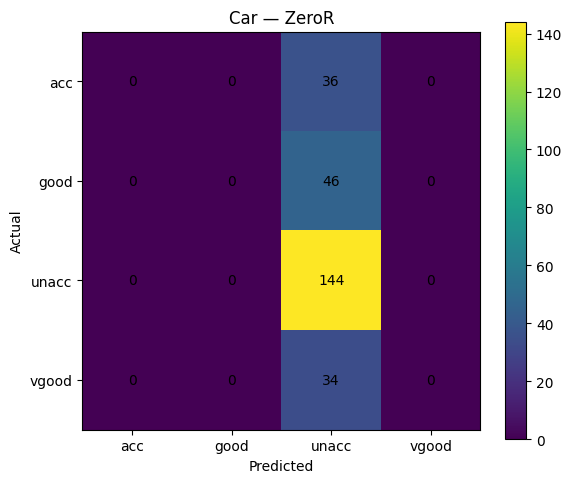

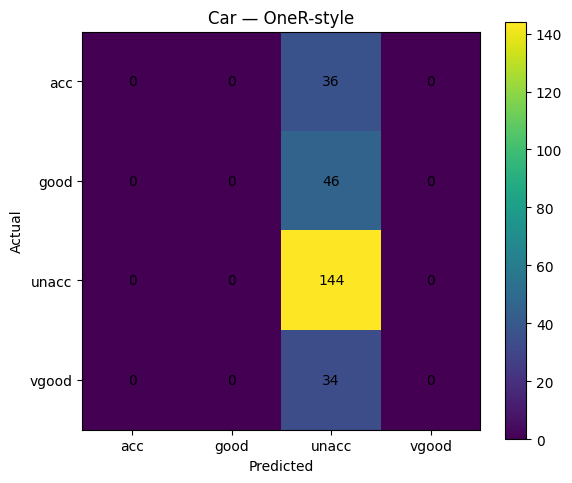

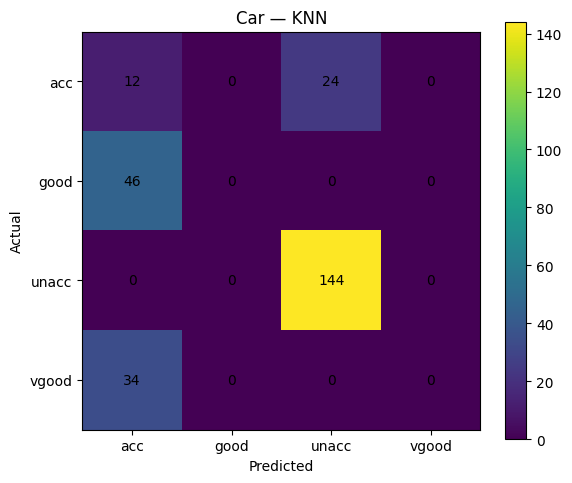

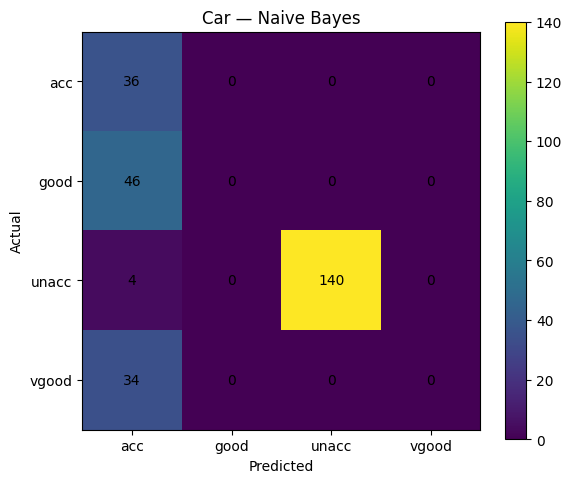

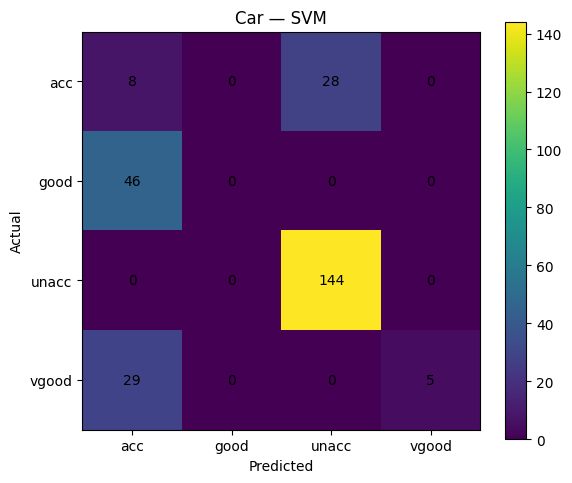

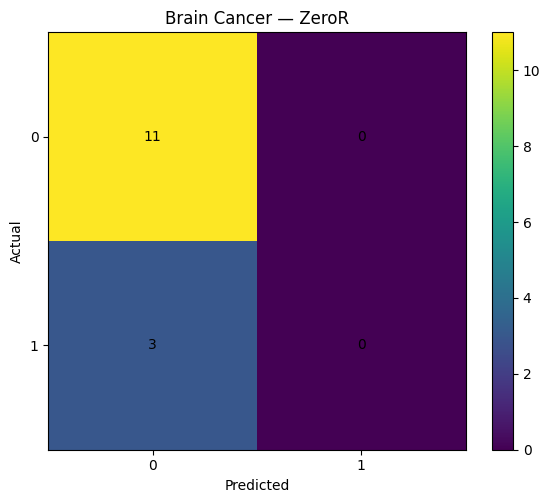

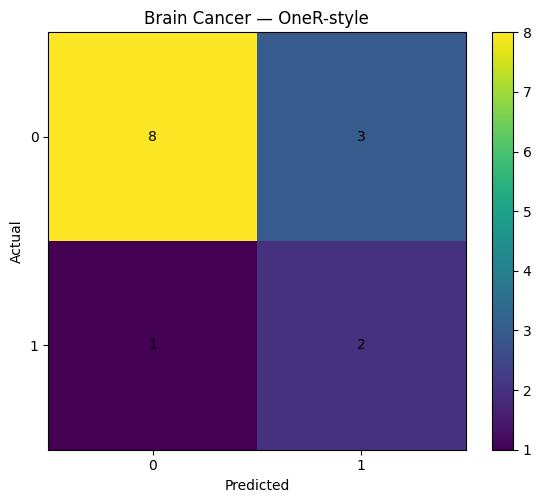

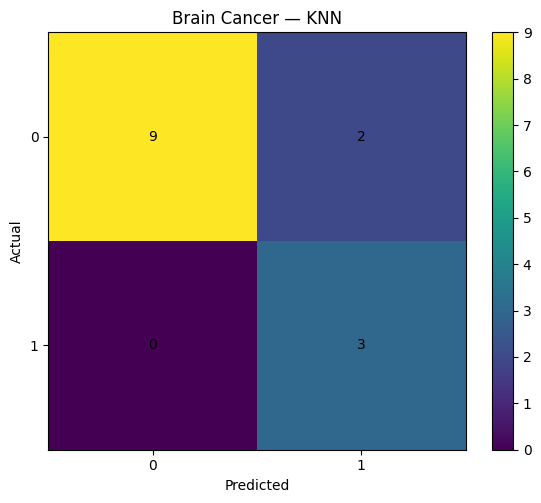

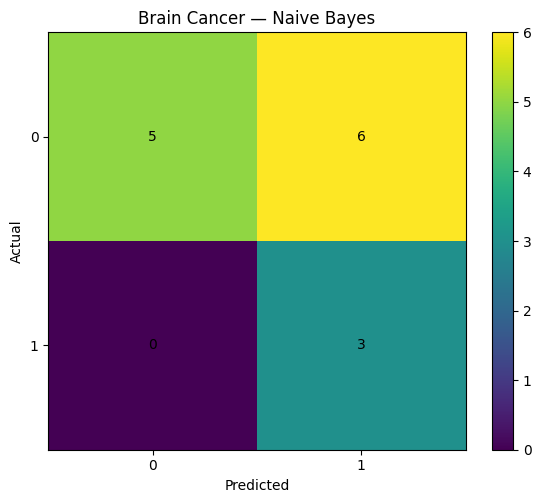

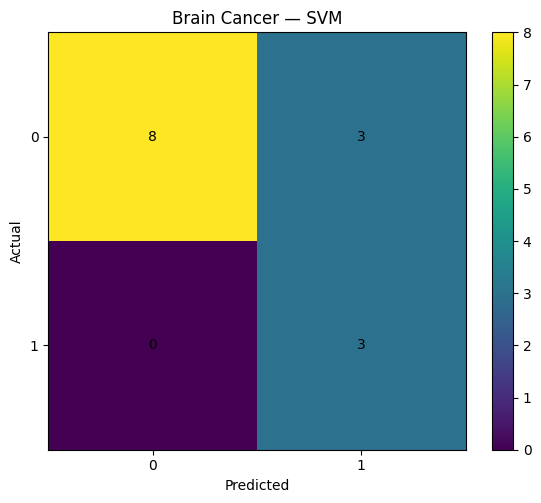

In [49]:

for title, y_true, pred in [
    ("Car — ZeroR", y_car_test, zeroR_car_test_pred),
    ("Car — OneR-style", y_car_test, oneR_car_test_pred),
    ("Car — KNN", y_car_test, knn_car_test_pred),
    ("Car — Naive Bayes", y_car_test, nb_car_test_pred),
    ("Car — SVM", y_car_test, svm_car_test_pred),
    ("Brain Cancer — ZeroR", y_brain_test, zeroR_brain_test_pred),
    ("Brain Cancer — OneR-style", y_brain_test, oneR_brain_test_pred),
    ("Brain Cancer — KNN", y_brain_test, knn_brain_test_pred),
    ("Brain Cancer — Naive Bayes", y_brain_test, nb_brain_test_pred),
    ("Brain Cancer — SVM", y_brain_test, svm_brain_test_pred)
]:
    show_confusion_matrix(y_true, pred, title)


# 7. Regression Plots

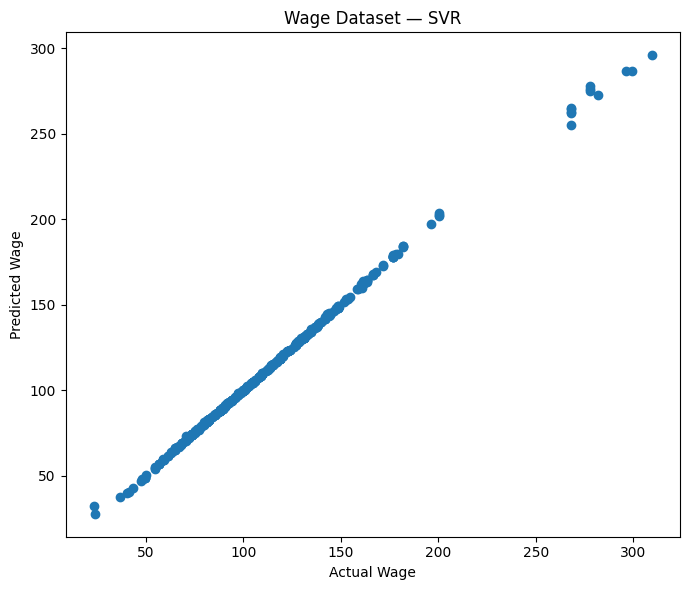

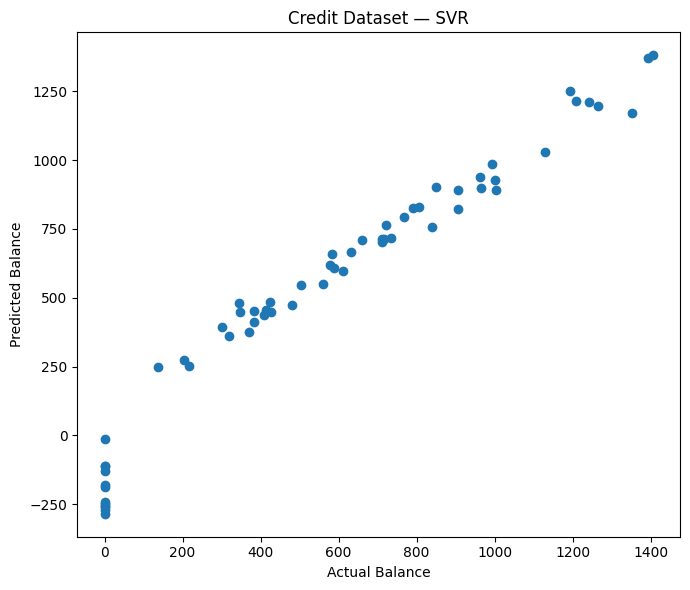

In [50]:

plt.figure(figsize=(7, 6))
plt.scatter(y_wage_test, wage_test_pred)
plt.xlabel("Actual Wage")
plt.ylabel("Predicted Wage")
plt.title("Wage Dataset — SVR")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(y_credit_test, credit_test_pred)
plt.xlabel("Actual Balance")
plt.ylabel("Predicted Balance")
plt.title("Credit Dataset — SVR")
plt.tight_layout()
plt.show()


# 8. Export Results

In [51]:

classification_results_df.to_csv("Assignment5_Classification_Results.csv", index=False)
regression_results_df.to_csv("Assignment5_Regression_Results.csv", index=False)

print("Results exported successfully.")


Results exported successfully.
